In [14]:
!pip install chess


Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1147, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 690, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/spinners.py", line 9, in <module>
    from pip._internal.utils.logging import get_indentation
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/utils/logging.py", line 22, in <module>
    from pip._vendor.rich.logging import RichHandler
  File "/usr/local/lib/python3.11/dist-packages/pip/_vendor/rich/logging.py", line 15, in <module>
    from .traceback import Traceback
  File "/usr/local/lib/python3.11/dist-packages/pip/_vendor/rich/traceback.py", line 38, in <module>
    from .syntax import Syntax
  File "/usr/l

In [15]:
pip install chess cairosvg imageio


In [ ]:
!pip install cairosvg


In [19]:

import chess
import chess.svg
import cairosvg
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from PIL import Image
import io
import os

# piece values
piece_values = {
    chess.PAWN: 100,
    chess.KNIGHT: 320,
    chess.BISHOP: 330,
    chess.ROOK: 500,
    chess.QUEEN: 900,
    chess.KING: 20000
}

# evaluation function
def evaluate(board):
    if board.is_checkmate():
        return -9999 if board.turn else 9999
    if board.is_stalemate() or board.is_insufficient_material():
        return 0

    eval = 0

    # Material
    for piece_type in piece_values:
        eval += len(board.pieces(piece_type, chess.WHITE)) * piece_values[piece_type]
        eval -= len(board.pieces(piece_type, chess.BLACK)) * piece_values[piece_type]

    # Center control bonus
    center_squares = [chess.D4, chess.E4, chess.D5, chess.E5]
    for square in center_squares:
        piece = board.piece_at(square)
        if piece:
            if piece.color == chess.WHITE:
                eval += 20
            else:
                eval -= 20

    # Mobility bonus
    mobility = len(list(board.legal_moves))
    eval += mobility * (10 if board.turn else -10)

    return eval

# Alpha-beta pruning
def alpha_beta(board, depth, alpha, beta, maximizing_player):
    if depth == 0 or board.is_game_over():
        return evaluate(board), None

    best_move = None

    if maximizing_player:
        max_eval = -float('inf')
        for move in board.legal_moves:
            board.push(move)
            eval, _ = alpha_beta(board, depth-1, alpha, beta, False)
            board.pop()
            if eval > max_eval:
                max_eval = eval
                best_move = move
            alpha = max(alpha, eval)
            if beta <= alpha:
                break
        return max_eval, best_move
    else:
        min_eval = float('inf')
        for move in board.legal_moves:
            board.push(move)
            eval, _ = alpha_beta(board, depth-1, alpha, beta, True)
            board.pop()
            if eval < min_eval:
                min_eval = eval
                best_move = move
            beta = min(beta, eval)
            if beta <= alpha:
                break
        return min_eval, best_move

# Save board
def board_to_image(board, last_move=None):
    svg_data = chess.svg.board(board=board, lastmove=last_move, size=400)
    png_data = cairosvg.svg2png(bytestring=svg_data.encode('utf-8'))
    img = Image.open(io.BytesIO(png_data)).convert('RGB')
    return img

# Main simulation
board = chess.Board()
images = []
depth = 4
max_moves = 300
move_counter = 0

while not board.is_game_over() and move_counter < max_moves:
    eval, move = alpha_beta(board, depth, -float('inf'), float('inf'), board.turn)
    if move is None:
        break
    board.push(move)
    img = board_to_image(board, last_move=move)
    images.append(img)
    move_counter += 1

# winner frame
final_img = board_to_image(board)
images.append(final_img)

# Save as GIF
gif_path = "/content/chess_game.gif"
images[0].save(gif_path, save_all=True, append_images=images[1:], duration=500, loop=0)

# Show result
print(f"Game Over: {board.result()}")
print(f"GIF Saved Successfully: {gif_path} ✅")


Game Over: 1-0
GIF Saved Successfully: /content/chess_game.gif ✅


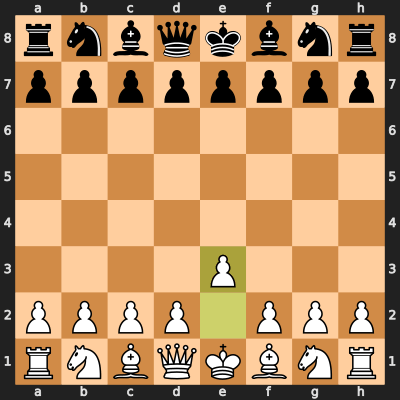

In [20]:
from IPython.display import Image

# Display the GIF
Image(filename="/content/chess_game.gif")


In [21]:
from google.colab import files
files.download("/content/chess_game.gif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>